# HyperKvasir CLIP embeddings + linear classifier

Extract frozen CLIP image embeddings and train a shallow linear classifier as a cheap baseline.

In [1]:
import os
from pathlib import Path
import json
import random
from typing import Tuple

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from transformers import CLIPProcessor, CLIPModel

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [2]:
# Paths & config
def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root containing '0_dataset_prep'. cwd={start}")

DATA_ROOT = find_dataset_root()
META_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "metadata_enriched.csv"
LABEL_MAP_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "label_map.csv"
OUT_DIR = DATA_ROOT / "3_feature_extraction" / "out" / "clip_linear"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "openai/clip-vit-base-patch32"
BATCH_SIZE = 16
NUM_WORKERS = 0  # set >0 if you want multiprocessing
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Data root:", DATA_ROOT)
print("Output dir:", OUT_DIR)


Device: cuda
Data root: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir
Output dir: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir/3_feature_extraction/out/clip_linear


In [3]:
# Load metadata
meta = pd.read_csv(META_CSV)
images_base = DATA_ROOT / "0_dataset_prep"

def to_abs(p):
    p = Path(p)
    if p.is_absolute():
        return p
    return (images_base / p).resolve()

meta["image_path"] = meta["image_path"].apply(lambda p: str(to_abs(p)))

if LABEL_MAP_CSV.exists():
    label_map = pd.read_csv(LABEL_MAP_CSV)
    id_to_name = dict(zip(label_map.label_id, label_map.label_name))
else:
    id_to_name = {i: name for i, name in enumerate(sorted(meta.label_name.unique()))}
name_to_id = {v: k for k, v in id_to_name.items()}
meta["label_id"] = meta["label_name"].map(name_to_id)

meta = meta[meta["image_path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)
print("After filtering images:", meta.shape)
print(meta["split"].value_counts())


After filtering images: (10662, 7)
split
train         8528
validation    1069
test          1065
Name: count, dtype: int64


In [4]:
# Dataset
class ImageDS(Dataset):
    def __init__(self, df: pd.DataFrame, processor):
        self.paths = df["image_path"].tolist()
        self.labels = df["label_id"].astype(int).tolist()
        self.processor = processor
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        encoded = self.processor(images=img, return_tensors="pt")
        return encoded, self.labels[idx]

def collate_fn(batch):
    # batch is list of (encoded, label)
    pixel_values = torch.cat([b[0]["pixel_values"] for b in batch], dim=0)
    labels = torch.tensor([b[1] for b in batch], dtype=torch.long)
    return pixel_values, labels


In [5]:
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
clip_model.eval()
print("Loaded CLIP")


/home/aristotle/anaconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded CLIP


In [6]:
def extract_split(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
    ds = ImageDS(df, processor)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    feats, labels = [], []
    with torch.no_grad():
        for pixels, y in tqdm(dl, desc="embed", leave=False):
            pixels = pixels.to(DEVICE)
            out = clip_model.get_image_features(pixel_values=pixels)
            feats.append(out.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(labels, axis=0)


In [7]:
# Extract embeddings per split
train_df = meta[meta["split"] == "train"].reset_index(drop=True)
val_df   = meta[meta["split"] == "validation"].reset_index(drop=True)
test_df  = meta[meta["split"] == "test"].reset_index(drop=True)

print({"train": len(train_df), "val": len(val_df), "test": len(test_df)})

train_X, train_y = extract_split(train_df)
val_X,   val_y   = extract_split(val_df)
test_X,  test_y  = extract_split(test_df)


{'train': 8528, 'val': 1069, 'test': 1065}


embed:   0%|          | 0/533 [00:00<?, ?it/s]

embed:   0%|          | 0/67 [00:00<?, ?it/s]

embed:   0%|          | 0/67 [00:00<?, ?it/s]

In [8]:
# Train logistic regression on CLIP embeddings
scaler = StandardScaler()
train_Xs = scaler.fit_transform(train_X)
val_Xs   = scaler.transform(val_X)
test_Xs  = scaler.transform(test_X)

clf = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    class_weight="balanced",
    n_jobs=-1,
)
clf.fit(train_Xs, train_y)

val_pred  = clf.predict(val_Xs)
test_pred = clf.predict(test_Xs)


/home/aristotle/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [9]:
# Summarize metrics
def summarize(y_true, y_pred):
    labels = sorted(id_to_name.keys())
    target_names = [id_to_name[i] for i in labels]
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return report, cm

val_report, val_cm = summarize(val_y, val_pred)
test_report, test_cm = summarize(test_y, test_pred)

print("Val accuracy:", val_report["accuracy"])
print("Test accuracy:", test_report["accuracy"])


Val accuracy: 0.8278765201122544
Test accuracy: 0.8619718309859155


In [10]:
# Save metrics
with open(OUT_DIR / "metrics_val.json", "w") as f:
    json.dump(val_report, f, indent=2)
with open(OUT_DIR / "metrics_test.json", "w") as f:
    json.dump(test_report, f, indent=2)

pd.DataFrame(val_report).T.to_csv(OUT_DIR / "metrics_val.csv")
pd.DataFrame(test_report).T.to_csv(OUT_DIR / "metrics_test.csv")

np.save(OUT_DIR / "confusion_val.npy", val_cm)
np.save(OUT_DIR / "confusion_test.npy", test_cm)

pred_df = pd.DataFrame({
    "split": ["val"] * len(val_y) + ["test"] * len(test_y),
    "y_true": np.concatenate([val_y, test_y]),
    "y_pred": np.concatenate([val_pred, test_pred]),
})
pred_df.to_csv(OUT_DIR / "predictions_val_test.csv", index=False)

print("Saved metrics to", OUT_DIR)


Saved metrics to /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir/3_feature_extraction/out/clip_linear


Saved confusion matrix to /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir/3_feature_extraction/out/clip_linear/confusion_test.png


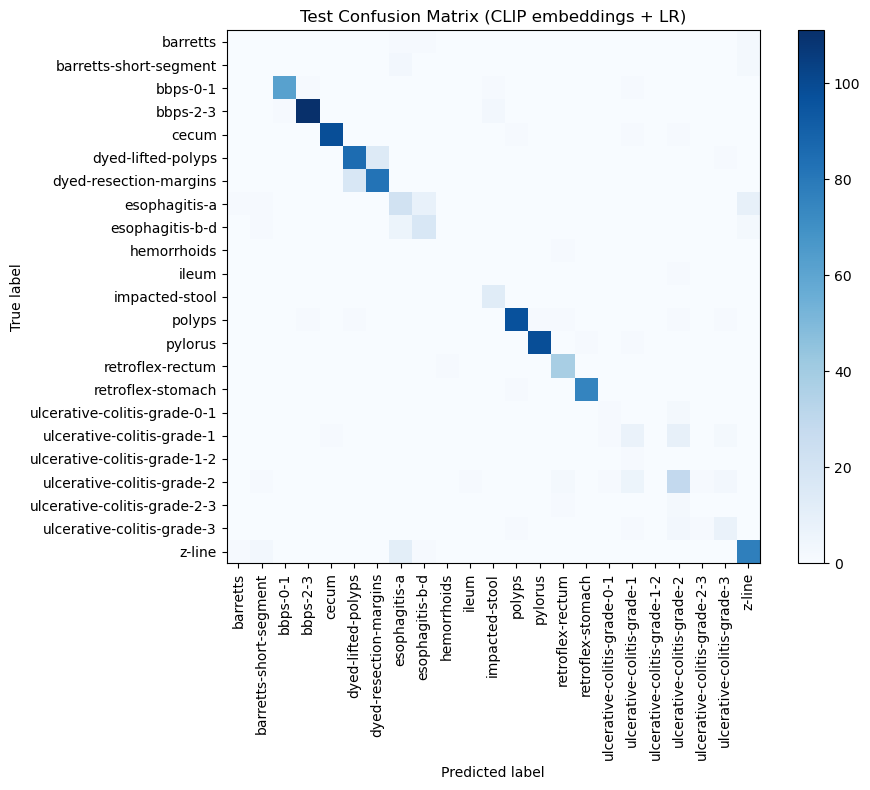

In [11]:
# Plot confusion matrix for test split
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=[id_to_name[i] for i in sorted(id_to_name)])
disp.plot(include_values=False, cmap="Blues", ax=ax, xticks_rotation=90)
plt.title("Test Confusion Matrix (CLIP embeddings + LR)")
plt.tight_layout()
fig_path = OUT_DIR / "confusion_test.png"
plt.savefig(fig_path, dpi=200)
print("Saved confusion matrix to", fig_path)
